In [8]:

import torch 
from scipy.signal import find_peaks
from utils import create_uniform_energy_grid, shift_test_batch
from models import MultiClassifierV2_STN


In [2]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Optionally, you can print more details about the GPU if available
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs available: {torch.cuda.device_count()}")

Using device: cuda
GPU Name: Tesla T4
Number of GPUs available: 1


In [3]:
import torch

# Load the entire dictionary object
test_data = torch.load('../data/synthetic_data_hard_final/test_data.pt')

# Access each item by its key
X_test = test_data['features']
y_test = test_data['labels']


# Now you can use these tensors for evaluation
print(f"Loaded features shape: {X_test.shape}")
print(f"Loaded labels shape: {y_test.shape}")

# If you need a DataLoader for batching during evaluation:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(X_test, y_test)
test_loader_new = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loaded features shape: torch.Size([20000, 6601])
Loaded labels shape: torch.Size([20000, 40])


In [4]:
# ✅ Correct import
from pathlib import Path

# 4. Create an instance of the model and send it to target device
model_0 = MultiClassifierV2_STN().to(device)

# Load the saved model
model_path = Path("../../../local_models/STN_3_shift.pth")


model_0.load_state_dict(torch.load(model_path))
model_0.eval()

MultiClassifierV2_STN(
  (stn): STN1D(
    (localization): Sequential(
      (0): Linear(in_features=6601, out_features=64, bias=True)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=64, out_features=32, bias=True)
      (3): ReLU(inplace=True)
      (4): Linear(in_features=32, out_features=2, bias=True)
    )
  )
  (layer_1): Linear(in_features=6601, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer_2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer_3): Linear(in_features=128, out_features=40, bias=True)
  (activation): LeakyReLU(negative_slope=0.01)
  (dropout): Dropout(p=0.1, inplace=False)
)

In [5]:
MAX_SHIFT_IN_INDICES = 30
# Create the new, randomly shifted test set
X_test_shifted = shift_test_batch(X_test, MAX_SHIFT_IN_INDICES)
X_test_shifted = X_test_shifted.to(device)

# --- Now run inference using the SHIFTED data ---
with torch.inference_mode():
    # Pass the shifted tensor to your model
    test_logits, aligned_spectra = model_0(X_test_shifted)
    
    # The rest of your code remains the same...
    test_pred = torch.round(torch.sigmoid(test_logits.squeeze()))

print("✅ Inference complete on randomly shifted test data.")

✅ Inference complete on randomly shifted test data.


[168.6 169.6 285.5 289.1 291.8 292.2 400.7 531.7 533.3]
[167.6 168.8 284.9 288.5 291.2 291.6 400.4 531.9 533.4]


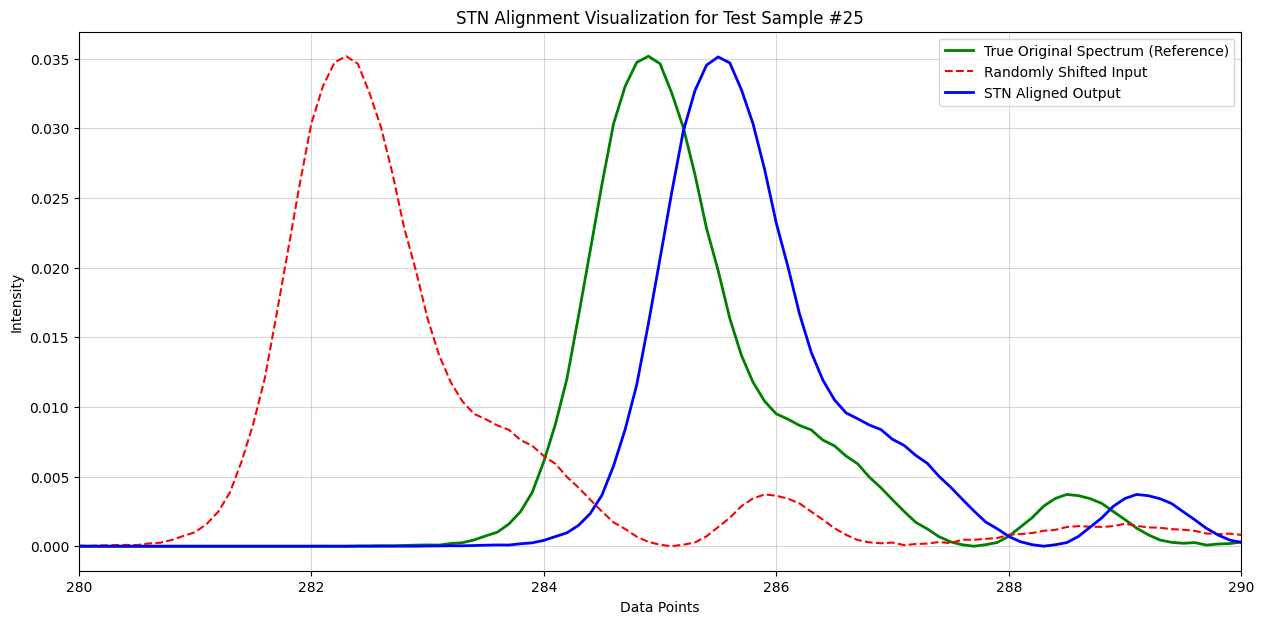

In [14]:
import matplotlib.pyplot as plt
import numpy as np




valence_region_index =400 
start_energy, end_energy = (0,700)

BE_values = create_uniform_energy_grid(start_energy, end_energy)[valence_region_index:]

# Choose an index to inspect
index = 25

# --- Retrieve all three versions of the spectrum ---
# 1. The true original spectrum (before any shifting)
true_original_spec = X_test[index].cpu().numpy()

# 2. The randomly shifted spectrum that was fed into the model
shifted_input_spec = X_test_shifted[index].cpu().numpy()

# 3. The spectrum after the STN tried to align it
aligned_output_spec = aligned_spectra[index].cpu().numpy()


# --- Create the plot ---
plt.figure(figsize=(15, 7))

# Plot the true original spectrum as a reference
plt.plot(BE_values, true_original_spec, label='True Original Spectrum (Reference)', color='green', linewidth=2)

# Plot the randomly shifted input
plt.plot(BE_values, shifted_input_spec, label='Randomly Shifted Input', color='red', linestyle='--')

# Plot the STN's aligned output
plt.plot(BE_values, aligned_output_spec, label='STN Aligned Output', color='blue', linewidth=2)

alligned_peaks, properties = find_peaks(aligned_output_spec, height=0.001, width =1)
print((alligned_peaks+400)/10)


original_peaks, properties = find_peaks(true_original_spec, height=0.001, width =1)
print((original_peaks+400)/10)

plt.title(f"STN Alignment Visualization for Test Sample #{index}")
plt.xlabel("Data Points")
plt.ylabel("Intensity")
plt.legend()
plt.xlim(280,290) # Keep the zoom on the area of interest
plt.grid(True, alpha=0.5)
plt.show()

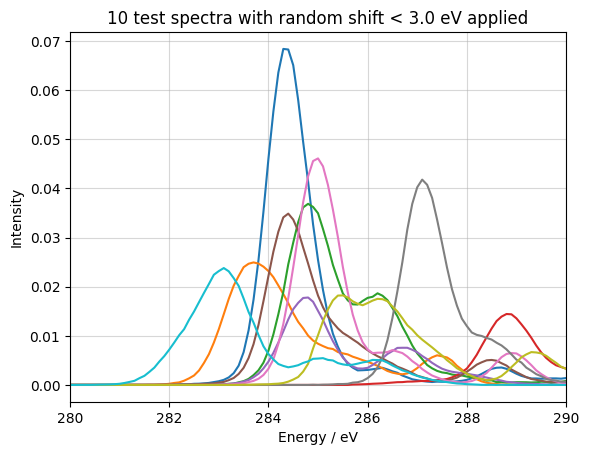

In [13]:
example_indices = list(range(0,10,1))

for index in example_indices:
    shifted_input_spec = X_test_shifted[index].cpu().numpy()
    plt.plot(BE_values, shifted_input_spec, label='STN Aligned Output')
    

plt.title(f"10 test spectra with random shift < 3.0 eV applied")
plt.xlabel("Energy / eV")
plt.ylabel("Intensity")
plt.xlim(280,290) # Keep the zoom on the area of interest
plt.grid(True, alpha=0.5)
plt.show()
    

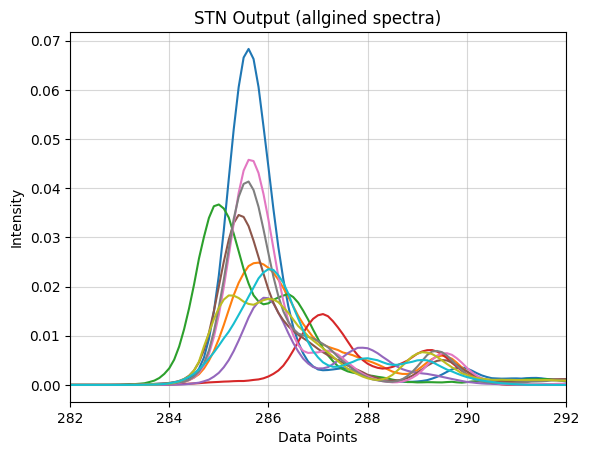

In [14]:
example_indices = list(range(0,10,1))

for index in example_indices:
    aligned_output_spec = aligned_spectra[index].cpu().numpy()
    plt.plot(BE_values, aligned_output_spec, label='STN Aligned Output')
    

plt.title(f"STN Output (allgined spectra)")
plt.xlabel("Data Points")
plt.ylabel("Intensity")
plt.xlim(282,292) # Keep the zoom on the area of interest
plt.grid(True, alpha=0.5)
plt.show()
    

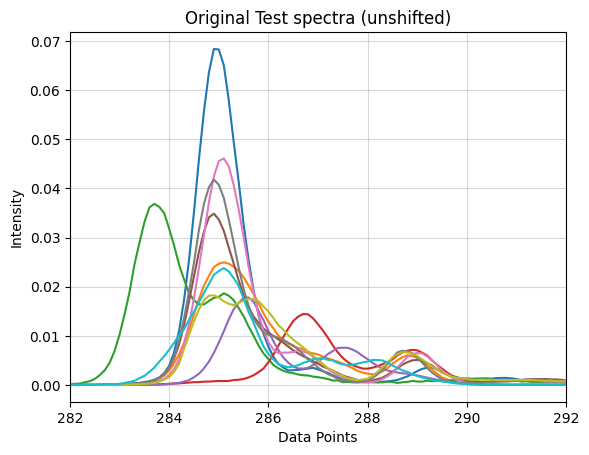

In [15]:
example_indices = list(range(0,10,1))

for index in example_indices:
    true_original_spec = X_test[index].cpu().numpy()
    plt.plot(BE_values, true_original_spec, label='STN Aligned Output')
    

plt.title(f"Original Test spectra (unshifted)")
plt.xlabel("Data Points")
plt.ylabel("Intensity")
plt.xlim(282,292) # Keep the zoom on the area of interest
plt.grid(True, alpha=0.5)
plt.show()
    